In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import deque

In [33]:
def exp_func(lmbd, p):
    return -1 / lmbd * np.log(p)

def generate_request_time_exp(lmbd, work_time):
    T_server = [0]
    while True:
        new_t = T_server[-1] + exp_func(lmbd, np.random.rand())
        if new_t > work_time:
            break
        T_server.append(new_t)
    T_server.pop(0)
    return np.asarray(T_server)

def generate_process_time_exp(lmbd, n):
    return exp_func(lmbd, np.random.rand(n))

def simulate(Ts, Tz, n):
    processed_signals = 0
    ends = [0] * n
    work_times = [0] * n
    rej_time = 0
    free_time = 0
    for i in range(len(Ts)):
        if np.min(ends) <= Ts[i]:
            if np.max(ends) <= Ts[i]:
                free_time += Ts[i] - np.max(ends)

            server_idx = ends.index(np.min(ends))
            work_times[server_idx] += Tz[i]
            ends[server_idx] = Ts[i] + Tz[i]
            processed_signals += 1

            if np.min(ends) > Ts[i]:
                rej_time += np.min(ends) - Ts[i]


    work_times = np.asarray(work_times)
    return processed_signals, work_times, free_time, rej_time


In [44]:
mu = 0.1
lmbd = 0.2
T = 1000
n = 2
T_req = generate_request_time_exp(lmbd, T)
T_processing = generate_process_time_exp(mu, len(T_req))

processed_signals, work_times, free_time, rej_time = simulate(T_req, T_processing, n)
print(f"Число обработанных сигналов: {processed_signals}")
print(f"Число отказов: {len(T_req) - processed_signals}")
print(f"Вероятность обработки заявки: {processed_signals / len(T_req)}")
print(f"Вероятность отказа в обслуживании: {1 - (processed_signals / len(T_req))}")
print(f"Время простоя каналов: {T - work_times}")
print(f"Вероятность загрузки каналов: {work_times / T}")

Число обработанных сигналов: 114
Число отказов: 85
Вероятность обработки заявки: 0.5728643216080402
Вероятность отказа в обслуживании: 0.42713567839195976
Время простоя каналов: [362.47805409 341.02623039]
Вероятность загрузки каналов: [0.63752195 0.65897377]


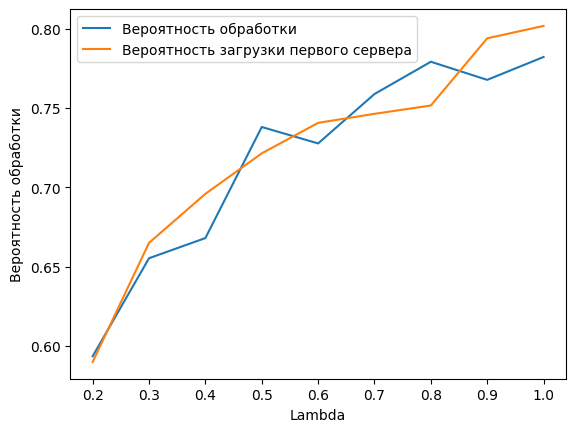

,Qn,Tn
"n = 2, lmbd = 0.2",0.593420,0.589838
"n = 3, lmbd = 0.3",0.655260,0.664973
"n = 4, lmbd = 0.4",0.667986,0.695877
"n = 5, lmbd = 0.5",0.738062,0.721435
"n = 6, lmbd = 0.6",0.727697,0.740678
"n = 7, lmbd = 0.7",0.758868,0.746372
"n = 8, lmbd = 0.8",0.779227,0.751619
"n = 9, lmbd = 0.9",0.767804,0.794011
"n = 10, lmbd = 1.0",0.782248,0.801832


In [46]:
mu = 0.1
T = 1000

ns = np.arange(2, 11)
lmbds = ns * 0.1

all_ps = []
all_wts = []
for i in range(len(ns)):
    n = ns[i]
    lmbd = lmbds[i]

    c = 10
    cur_p = []
    cur_wt = []
    for _ in range(c):
        T_req = generate_request_time_exp(lmbd, T)
        T_processing = generate_process_time_exp(mu, len(T_req))

        processed_signals, work_times, free_time, rej_time = simulate(T_req, T_processing, n)

        cur_p.append(processed_signals / len(T_req))
        cur_wt.append(work_times[0] / T)
    all_ps.append(np.mean(cur_p))
    all_wts.append(np.mean(cur_wt))

plt.plot(lmbds, all_ps, label="Вероятность обработки")
plt.plot(lmbds, all_wts, label="Вероятность загрузки первого сервера")
plt.xlabel("Lambda")
plt.ylabel("Вероятность обработки")
plt.legend()
plt.show()

table_rows = [f"n = {n}, lmbd = {n * 0.1:.3}" for n in ns]
df = pd.DataFrame({"Qn": all_ps, "Tn": all_wts}, index=table_rows)
df

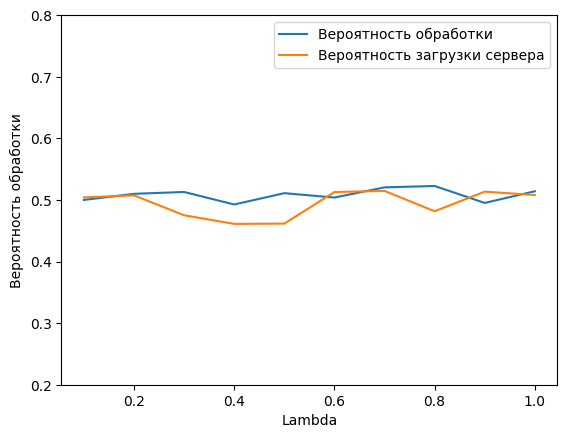

,Qn,Tn
"mu = 0.1, lmbd = 0.1",0.500000,0.504110
"mu = 0.2, lmbd = 0.2",0.509901,0.507378
"mu = 0.30000000000000004, lmbd = 0.30000000000000004",0.512903,0.475063
"mu = 0.4, lmbd = 0.4",0.492574,0.461115
"mu = 0.5, lmbd = 0.5",0.510965,0.461563
"mu = 0.6000000000000001, lmbd = 0.6000000000000001",0.503864,0.512795
"mu = 0.7000000000000001, lmbd = 0.7000000000000001",0.520376,0.514616
"mu = 0.8, lmbd = 0.8",0.522634,0.481592
"mu = 0.9, lmbd = 0.9",0.495125,0.513473
"mu = 1.0, lmbd = 1.0",0.514056,0.507978


In [55]:
n = 1
T = 1000

mus = np.arange(1, 11) * 0.1
lmbds = np.arange(1, 11) * 0.1

all_ps = []
all_wts = []
for i in range(len(mus)):
    mu = mus[i]
    lmbd = lmbds[i]

    c = 1
    cur_p = []
    cur_wt = []
    for _ in range(c):
        T_req = generate_request_time_exp(lmbd, T)
        T_processing = generate_process_time_exp(mu, len(T_req))

        processed_signals, work_times, free_time, rej_time = simulate(T_req, T_processing, n)

        cur_p.append(processed_signals / len(T_req))
        cur_wt.append(work_times[0] / T)
    all_ps.append(np.mean(cur_p))
    all_wts.append(np.mean(cur_wt))

plt.plot(lmbds, all_ps, label="Вероятность обработки")
plt.plot(lmbds, all_wts, label="Вероятность загрузки сервера")
plt.xlabel("Lambda")
plt.ylabel("Вероятность обработки")
plt.legend()
plt.ylim(0.2, 0.8)
plt.show()

table_rows = [f"mu = {mu}, lmbd = {mu}" for mu in mus]
df = pd.DataFrame({"Qn": all_ps, "Tn": all_wts}, index=table_rows)
df